In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

Taylor polynomial (sin, n=5): x**5/120 - x**3/6 + x
approx at pi/4: 0.7071430457793603
true sin(pi/4): 0.7071067811865476


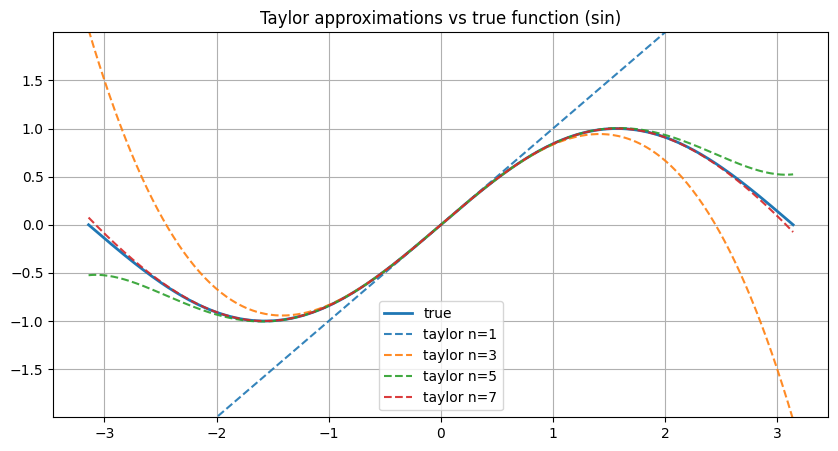

In [2]:
def taylor_expansion(expr, var='x', a=0, n=4):
    """Return the Taylor polynomial (sympy Expr) of `expr` around `a` up to order `n`."""
    x = sp.symbols(var)
    # Accept either a sympy expression or a string representing the expression
    if isinstance(expr, str):
        f = sp.sympify(expr)
    elif isinstance(expr, sp.Basic):
        f = expr
    else:
        raise ValueError('expr must be a sympy expression or a string')
    # series returns a Series object; remove the Big-O term and expand to polynomial
    series = sp.series(f, x, a, n+1).removeO()
    poly = sp.expand(series)
    return poly

def taylor_eval(expr, x_val, var='x', a=0, n=4):
    """Evaluate the Taylor polynomial of `expr` at numeric `x_val`."""
    poly = taylor_expansion(expr, var=var, a=a, n=n)
    fnum = sp.lambdify(sp.symbols(var), poly, 'numpy')
    return fnum(x_val)

# Example: Taylor expansion of sin(x) about 0 up to order 5
expr = 'sin(x)'
poly = taylor_expansion(expr, var='x', a=0, n=5)
print('Taylor polynomial (sin, n=5):', poly)

x0 = np.pi/4
print('approx at pi/4:', taylor_eval(expr, x0, var='x', a=0, n=5))
print('true sin(pi/4):', np.sin(x0))
# Plot multiple Taylor approximations vs the true function over a range
x_vals = np.linspace(-np.pi, np.pi, 400)
f_true = sp.lambdify(sp.symbols('x'), sp.sympify(expr), 'numpy')(x_vals)
n_list = [1, 3, 5, 7]
plt.figure(figsize=(10,5))
plt.plot(x_vals, f_true, label='true', linewidth=2, color='C0')
for i, n in enumerate(n_list, start=1):
    poly_n = taylor_expansion(expr, var='x', a=0, n=n)
    f_approx_n = sp.lambdify(sp.symbols('x'), poly_n, 'numpy')(x_vals)
    plt.plot(x_vals, f_approx_n, linestyle='--', label=f'taylor n={n}', alpha=0.9)
plt.ylim(np.min(f_true)-1, np.max(f_true)+1)
plt.legend()
plt.grid(True)
plt.title('Taylor approximations vs true function (sin)')
plt.show()